In [1]:
# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import sentence_transformers
import sklearn
import torch

import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception:
    FAISS_AVAILABLE = False
    faiss = None
    FAISS_READY = False


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("faiss:", faiss.__version__)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)
print("sentence-transformers:", sentence_transformers.__version__)


NumPy: 2.3.5
Pandas: 2.3.3
FAISS доступен: True
faiss: 1.13.2
sentence-transformers доступен: True
sentence-transformers: 5.3.0


In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)


Устройство для работы: cpu


In [35]:
documents = []

folder = "data"

for i, filename in enumerate(sorted(os.listdir(folder)), 1):
    if filename.endswith(".md"):
        path = os.path.join(folder, filename)

        with open(path, "r", encoding="utf-8") as f:
            content = f.read()

        lines = content.split("\n")
        title = lines[0].replace("# ", "").strip()
        text = "\n".join(lines[1:]).strip()

        documents.append({
            "doc_id": f"doc_{i:02d}",
            "title": title,
            "text": text
        })

In [36]:
docs_df = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df))


Размер корпуса: 12


In [37]:
display(docs_df.head())

,doc_id,title,text
0,doc_01,Git Branch,A branch in Git is a lightweight movable point...
1,doc_02,Git Commit,A commit in Git is a snapshot of the repositor...
2,doc_03,Merge Conflicts,A merge conflict occurs when Git cannot automa...
3,doc_04,What is Git,Git is a distributed version control system us...
4,doc_05,Git Log,Git log shows the commit history of a reposito...


Предметная область — это основы работы с Git. В базе знаний рассматриваются ключевые концепции: коммиты, ветки, слияние, перебазирование, разрешение конфликтов и типичный рабочий процесс.

Эта область хорошо подходит для задач retrieval и построения mini-RAG, потому что состоит из чётко структурированных, но при этом насыщенных текстов. Многие понятия близки по смыслу (например, merge и rebase, reset и revert), поэтому простого поиска по ключевым словам недостаточно - требуется учитывать контекст запроса.

In [38]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 22, overlap: int = 5) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)


chunks_df = build_chunks_dataframe(documents, chunk_size=22, overlap=5)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(10))

Количество чанков: 44


,doc_id,title,chunk_id,chunk_text,n_words
0,doc_01,Git Branch,0,A branch in Git is a lightweight movable point...,22
1,doc_01,Git Branch,1,on different features independently without af...,22
2,doc_01,Git Branch,2,fixing - experimentation Example: git branch f...,20
3,doc_02,Git Commit,0,A commit in Git is a snapshot of the repositor...,22
4,doc_02,Git Commit,1,commit contains: - a unique identifier (hash) ...,22
5,doc_02,Git Commit,2,Commits allow developers to save progress and ...,22
6,doc_02,Git Commit,3,Good commit messages are short but descriptive...,14
7,doc_03,Merge Conflicts,0,A merge conflict occurs when Git cannot automa...,22
8,doc_03,Merge Conflicts,1,the same line was modified in both branches - ...,22
9,doc_03,Merge Conflicts,2,it Git marks conflicts in the file and require...,22


chunk_size и overlap были выбраны, потому что они обеспечивают разумный баланс между сохранением контекста и точностью поиска: чанк достаточно мал, чтобы не включать лишнюю информацию, но при этом достаточно велик, чтобы содержать законченную мысль, а overlap позволяет избежать потери смысла на границах фрагментов и повышает вероятность извлечения нужного контекста.

In [39]:
# Единый интерфейс для двух вариантов векторизации: dense embeddings и fallback.
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [40]:
# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (44, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


In [41]:
# Считаем сходство запроса и всех чанков без FAISS.
query = "What is Git?"
query_vector = embedder.encode_queries([query])

# Для нормализованных векторов это эквивалент косинусного сходства.
manual_scores = (chunk_embeddings @ query_vector.T).ravel()

top_k = 5
top_indices = np.argsort(manual_scores)[::-1][:top_k]

manual_results_df = chunks_df.iloc[top_indices].copy()
manual_results_df["score"] = manual_scores[top_indices]
manual_results_df["score"] = manual_results_df["score"].round(4)
manual_results_df.insert(0, "rank", range(1, len(manual_results_df) + 1))

display(Markdown(f"**Запрос:** {query}"))
display(manual_results_df[["rank", "doc_id", "title", "chunk_id", "score", "chunk_text"]])

**Запрос:** What is Git?

,rank,doc_id,title,chunk_id,score,chunk_text
11,1,doc_04,What is Git,0,0.7653,Git is a distributed version control system us...
16,2,doc_04,What is Git,5,0.7173,widely used in modern software development and...
15,3,doc_04,What is Git,4,0.6841,Git include: - branching and merging - distrib...
9,4,doc_03,Merge Conflicts,2,0.6594,it Git marks conflicts in the file and require...
3,5,doc_02,Git Commit,0,0.6444,A commit in Git is a snapshot of the repositor...


In [42]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [43]:
# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)


# Проверяем FAISS-поиск на первом запросе.
# Результаты должны совпасть с ручным расчётом из секции 6:
# тот же top-k, те же фрагменты, те же оценки сходства.
faiss_query = "What is Git?"
faiss_results_df = search_similar_chunks(faiss_query, top_k=5)

display(Markdown(f"**Запрос:** {faiss_query}"))
display(faiss_results_df)

**Запрос:** What is Git?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_04,What is Git,0,0.7653,Git is a distributed version control system us...
1,2,doc_04,What is Git,5,0.7173,widely used in modern software development and...
2,3,doc_04,What is Git,4,0.6841,Git include: - branching and merging - distrib...
3,4,doc_03,Merge Conflicts,2,0.6594,it Git marks conflicts in the file and require...
4,5,doc_02,Git Commit,0,0.6444,A commit in Git is a snapshot of the repositor...


In [44]:
# Проверяем retrieval на нескольких запросах.
example_queries = [
    "What is Git?",
    "What is commit in Git?",
    "How to resolve Git conflict?",
    "Which is Git workflow example?",
    "What are the differences between Git merge and rebase?",
]

for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `What is Git?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_04,What is Git,0,0.7653,Git is a distributed version control system us...
1,2,doc_04,What is Git,5,0.7173,widely used in modern software development and...
2,3,doc_04,What is Git,4,0.6841,Git include: - branching and merging - distrib...


### Запрос: `What is commit in Git?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_02,Git Commit,0,0.8304,A commit in Git is a snapshot of the repositor...
1,2,doc_04,What is Git,3,0.7691,Each commit represents the state of the projec...
2,3,doc_06,Git Merge,0,0.7334,Git merge is used to combine changes from one ...


### Запрос: `How to resolve Git conflict?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_03,Merge Conflicts,2,0.8603,it Git marks conflicts in the file and require...
1,2,doc_03,Merge Conflicts,0,0.6622,A merge conflict occurs when Git cannot automa...
2,3,doc_07,Merge vs Rebase,0,0.6396,Git merge and git rebase are both used to inte...


### Запрос: `Which is Git workflow example?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_04,What is Git,4,0.8148,Git include: - branching and merging - distrib...
1,2,doc_12,Basic Git Workflow,2,0.7939,"-b feature git commit -m ""work"" git push origi..."
2,3,doc_12,Basic Git Workflow,0,0.7099,A typical Git workflow: 1. Clone repository 2....


### Запрос: `What are the differences between Git merge and rebase?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_07,Merge vs Rebase,0,0.8590,Git merge and git rebase are both used to inte...
1,2,doc_09,Git Rebase,0,0.8086,Git rebase is used to move or reapply commits ...
2,3,doc_06,Git Merge,0,0.7491,Git merge is used to combine changes from one ...


In [45]:
def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfFallbackBackend()




@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks_dataframe(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )

def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@k": metrics["hit"],
                f"recall@k": metrics["recall"],
                f"MRR@k": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)


In [46]:
# Собираем baseline-конфигурацию retriever.
baseline_chunk_size = 22
baseline_overlap = 5

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

# Посмотрим несколько контрольных запросов вручную.
sample_queries = [
    "What is Git?",
    "What is commit in Git?",
    "How to resolve Git conflict?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 44


,doc_id,title,chunk_id,chunk_text,n_words
0,doc_01,Git Branch,0,A branch in Git is a lightweight movable point...,22
1,doc_01,Git Branch,1,on different features independently without af...,22
2,doc_01,Git Branch,2,fixing - experimentation Example: git branch f...,20
3,doc_02,Git Commit,0,A commit in Git is a snapshot of the repositor...,22
4,doc_02,Git Commit,1,commit contains: - a unique identifier (hash) ...,22


### Запрос: What is Git?

,rank,score,doc_id,title,chunk_text
0,1,0.765282,doc_04,What is Git,Git is a distributed version control system us...
1,2,0.717349,doc_04,What is Git,widely used in modern software development and...
2,3,0.684086,doc_04,What is Git,Git include: - branching and merging - distrib...


### Запрос: What is commit in Git?

,rank,score,doc_id,title,chunk_text
0,1,0.830395,doc_02,Git Commit,A commit in Git is a snapshot of the repositor...
1,2,0.769143,doc_04,What is Git,Each commit represents the state of the projec...
2,3,0.733410,doc_06,Git Merge,Git merge is used to combine changes from one ...


### Запрос: How to resolve Git conflict?

,rank,score,doc_id,title,chunk_text
0,1,0.860280,doc_03,Merge Conflicts,it Git marks conflicts in the file and require...
1,2,0.662218,doc_03,Merge Conflicts,A merge conflict occurs when Git cannot automa...
2,3,0.639642,doc_07,Merge vs Rebase,Git merge and git rebase are both used to inte...


In [47]:
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "What is Git and what is it used for?",
        "relevant_doc_ids": ["doc_04"],
    },
    {
        "query_id": "q02",
        "query": "What does a Git commit contain?",
        "relevant_doc_ids": ["doc_02"],
    },
    {
        "query_id": "q03",
        "query": "Why are branches used in Git?",
        "relevant_doc_ids": ["doc_01"],
    },
    {
        "query_id": "q04",
        "query": "How does git merge work?",
        "relevant_doc_ids": ["doc_06"],
    },
    {
        "query_id": "q05",
        "query": "What does git rebase do?",
        "relevant_doc_ids": ["doc_09"],
    },
    {
        "query_id": "q06",
        "query": "What is the difference between merge and rebase?",
        "relevant_doc_ids": ["doc_07"],
    },
    {
        "query_id": "q07",
        "query": "Why do merge conflicts happen?",
        "relevant_doc_ids": ["doc_03"],
    },
    {
        "query_id": "q08",
        "query": "What is git stash used for?",
        "relevant_doc_ids": ["doc_11"],
    },
    {
        "query_id": "q09",
        "query": "What is the difference between git reset and git revert?",
        "relevant_doc_ids": ["doc_10"],
    },
    {
        "query_id": "q10",
        "query": "What is the difference between git pull and git fetch?",
        "relevant_doc_ids": ["doc_08"],
    },
    {
        "query_id": "q11",
        "query": "How can I view Git commit history?",
        "relevant_doc_ids": ["doc_05"],
    },
    {
        "query_id": "q12",
        "query": "What is the basic Git workflow?",
        "relevant_doc_ids": ["doc_12"],
    },
]

In [48]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@k", "mean_recall@k", "mean_MRR@k"],
        "value": [
            baseline_eval_k3["hit@k"].mean(),
            baseline_eval_k3["recall@k"].mean(),
            baseline_eval_k3["MRR@k"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@k,recall@k,MRR@k,first_relevant_rank
0,q01,What is Git and what is it used for?,doc_04,doc_04,1,1.0,1.0,1
1,q02,What does a Git commit contain?,doc_02,"doc_02, doc_05, doc_04",1,1.0,1.0,1
2,q03,Why are branches used in Git?,doc_01,"doc_01, doc_09, doc_03",1,1.0,1.0,1
3,q04,How does git merge work?,doc_06,"doc_07, doc_06, doc_03",1,1.0,0.5,2
4,q05,What does git rebase do?,doc_09,"doc_09, doc_07, doc_04",1,1.0,1.0,1
5,q06,What is the difference between merge and rebase?,doc_07,"doc_07, doc_09",1,1.0,1.0,1
6,q07,Why do merge conflicts happen?,doc_03,"doc_03, doc_06",1,1.0,1.0,1
7,q08,What is git stash used for?,doc_11,"doc_04, doc_11",1,1.0,0.5,2
8,q09,What is the difference between git reset and g...,doc_10,"doc_10, doc_07, doc_09",1,1.0,1.0,1
9,q10,What is the difference between git pull and gi...,doc_08,"doc_08, doc_12, doc_04",1,1.0,1.0,1


,metric,value
0,mean_hit@k,1.000
1,mean_recall@k,1.000
2,mean_MRR@k,0.875


In [49]:
retrieval_eval = pd.DataFrame(
    {
        "query": baseline_eval_k3["query"],
        "expected_source": baseline_eval_k3["relevant_doc_ids"],
        "retrieved_sources": baseline_eval_k3["predicted_doc_ids"],
        "hit_at_k": baseline_eval_k3["hit@k"],
    }
)

display(retrieval_eval)

retrieval_eval.to_csv('artifacts/retrieval_eval.csv', index=False)

,query,expected_source,retrieved_sources,hit_at_k
0,What is Git and what is it used for?,doc_04,doc_04,1
1,What does a Git commit contain?,doc_02,"doc_02, doc_05, doc_04",1
2,Why are branches used in Git?,doc_01,"doc_01, doc_09, doc_03",1
3,How does git merge work?,doc_06,"doc_07, doc_06, doc_03",1
4,What does git rebase do?,doc_09,"doc_09, doc_07, doc_04",1
5,What is the difference between merge and rebase?,doc_07,"doc_07, doc_09",1
6,Why do merge conflicts happen?,doc_03,"doc_03, doc_06",1
7,What is git stash used for?,doc_11,"doc_04, doc_11",1
8,What is the difference between git reset and g...,doc_10,"doc_10, doc_07, doc_09",1
9,What is the difference between git pull and gi...,doc_08,"doc_08, doc_12, doc_04",1


In [50]:
chunk_configs = [
    {"chunk_size": 18},
    {"chunk_size": 28},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=baseline_overlap,
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": baseline_overlap,
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@k": eval_df["hit@k"].mean(),
            "mean_recall@k": eval_df["recall@k"].mean(),
            "mean_MRR@k": eval_df["MRR@k"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@k", "mean_MRR@k", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@k,mean_recall@k,mean_MRR@k
0,28,5,33,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.958333
1,18,5,55,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.916667


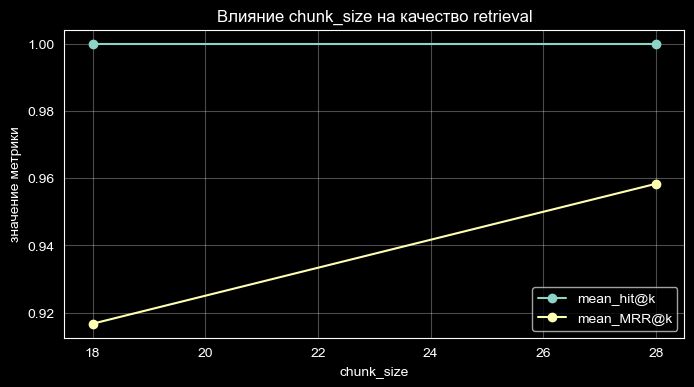

In [51]:
# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@k"], marker="o", label="mean_hit@k")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@k"], marker="o", label="mean_MRR@k")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_13",
        "title": "Git Tags",
        "text": (
            "Git tags are references to specific points in Git history, typically used to mark release versions. "
            "Tags are immutable and can be lightweight or annotated. "
            "Annotated tags contain metadata like the tagger, date, and a message, while lightweight tags are just pointers to commits."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Git Remote Repositories",
        "text": (
            "Remote repositories in Git allow collaboration between multiple developers. "
            "Common commands include `git remote add` to link a repository, `git fetch` to download changes, "
            "and `git push` to upload local commits. Managing remotes effectively is crucial for team workflows."
        ),
    },
]

updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "What are Git tags contain?",
    "What are git remote repositories commands?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_13,Git Tags
1,doc_14,Git Remote Repositories


### Как baseline-база отвечает на новые запросы

**Запрос:** What are Git tags contain?

,rank,score,doc_id,title,chunk_text
0,1,0.645074,doc_04,What is Git,Git is a distributed version control system us...
1,2,0.642799,doc_04,What is Git,Git include: - branching and merging - distrib...
2,3,0.632521,doc_05,Git Log,Git log shows the commit history of a reposito...


**Запрос:** What are git remote repositories commands?

,rank,score,doc_id,title,chunk_text
0,1,0.684003,doc_04,What is Git,widely used in modern software development and...
1,2,0.680070,doc_04,What is Git,Git is a distributed version control system us...
2,3,0.645296,doc_04,What is Git,Git include: - branching and merging - distrib...


In [53]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q13",
        "query": "What are Git tags and why are they used?",
        "relevant_doc_ids": ["doc_13"],
    },
    {
        "query_id": "q14",
        "query": "How do remote repositories work in Git and which commands are commonly used?",
        "relevant_doc_ids": ["doc_14"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@k", "mean_recall@k", "mean_MRR@k"],
        "before_update": [
            before_update_eval["hit@k"].mean(),
            before_update_eval["recall@k"].mean(),
            before_update_eval["MRR@k"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@k"].mean(),
            after_update_eval["recall@k"].mean(),
            after_update_eval["MRR@k"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@k_before,recall@k_before,MRR@k_before,first_relevant_rank_before,predicted_doc_ids_after,hit@k_after,recall@k_after,MRR@k_after,first_relevant_rank_after
0,q01,What is Git and what is it used for?,doc_04,doc_04,1,1.0,1.0,1.0,doc_04,1,1.0,1.0,1
1,q02,What does a Git commit contain?,doc_02,"doc_02, doc_05, doc_04",1,1.0,1.0,1.0,"doc_02, doc_05, doc_04",1,1.0,1.0,1
2,q03,Why are branches used in Git?,doc_01,"doc_01, doc_09, doc_03",1,1.0,1.0,1.0,"doc_01, doc_09, doc_03",1,1.0,1.0,1
3,q04,How does git merge work?,doc_06,"doc_07, doc_06, doc_03",1,1.0,0.5,2.0,"doc_07, doc_06, doc_03",1,1.0,0.5,2
4,q05,What does git rebase do?,doc_09,"doc_09, doc_07, doc_04",1,1.0,1.0,1.0,"doc_09, doc_07, doc_04",1,1.0,1.0,1
5,q06,What is the difference between merge and rebase?,doc_07,"doc_07, doc_09",1,1.0,1.0,1.0,"doc_07, doc_09",1,1.0,1.0,1
6,q07,Why do merge conflicts happen?,doc_03,"doc_03, doc_06",1,1.0,1.0,1.0,"doc_03, doc_06",1,1.0,1.0,1
7,q08,What is git stash used for?,doc_11,"doc_04, doc_11",1,1.0,0.5,2.0,"doc_04, doc_11",1,1.0,0.5,2
8,q09,What is the difference between git reset and g...,doc_10,"doc_10, doc_07, doc_09",1,1.0,1.0,1.0,"doc_10, doc_07, doc_09",1,1.0,1.0,1
9,q10,What is the difference between git pull and gi...,doc_08,"doc_08, doc_12, doc_04",1,1.0,1.0,1.0,"doc_08, doc_12, doc_04",1,1.0,1.0,1


,metric,before_update,after_update,delta
0,mean_hit@k,0.857143,1.000000,0.142857
1,mean_recall@k,0.857143,1.000000,0.142857
2,mean_MRR@k,0.750000,0.892857,0.142857


### Как updated-база отвечает на новые запросы

**Запрос:** What are Git tags contain?

,rank,score,doc_id,title,chunk_text
0,1,0.831059,doc_13,Git Tags,Git tags are references to specific points in ...
1,2,0.645074,doc_04,What is Git,Git is a distributed version control system us...
2,3,0.642799,doc_04,What is Git,Git include: - branching and merging - distrib...


**Запрос:** What are git remote repositories commands?

,rank,score,doc_id,title,chunk_text
0,1,0.832650,doc_14,Git Remote Repositories,Remote repositories in Git allow collaboration...
1,2,0.684003,doc_04,What is Git,widely used in modern software development and...
2,3,0.680070,doc_04,What is Git,Git is a distributed version control system us...


In [54]:
retrieval_before_after_update = pd.DataFrame(
    {
        "query": comparison_df["query"],
        "before_retrieved_sources": comparison_df["predicted_doc_ids_before"],
        "after_retrieved_sources": comparison_df["predicted_doc_ids_after"],
        "changed": comparison_df["predicted_doc_ids_before"] != comparison_df["predicted_doc_ids_after"]
    }
)

display(retrieval_before_after_update)

retrieval_before_after_update.to_csv("artifacts/retrieval_before_after_update.csv", index=False)

,query,before_retrieved_sources,after_retrieved_sources,changed
0,What is Git and what is it used for?,doc_04,doc_04,False
1,What does a Git commit contain?,"doc_02, doc_05, doc_04","doc_02, doc_05, doc_04",False
2,Why are branches used in Git?,"doc_01, doc_09, doc_03","doc_01, doc_09, doc_03",False
3,How does git merge work?,"doc_07, doc_06, doc_03","doc_07, doc_06, doc_03",False
4,What does git rebase do?,"doc_09, doc_07, doc_04","doc_09, doc_07, doc_04",False
5,What is the difference between merge and rebase?,"doc_07, doc_09","doc_07, doc_09",False
6,Why do merge conflicts happen?,"doc_03, doc_06","doc_03, doc_06",False
7,What is git stash used for?,"doc_04, doc_11","doc_04, doc_11",False
8,What is the difference between git reset and g...,"doc_10, doc_07, doc_09","doc_10, doc_07, doc_09",False
9,What is the difference between git pull and gi...,"doc_08, doc_12, doc_04","doc_08, doc_12, doc_04",False


In [55]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

In [56]:
def build_context_from_retrieval(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [57]:
query = "How do remote repositories work in Git and which commands are commonly used?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: How do remote repositories work in Git and which commands are commonly used?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.702565,doc_04,What is Git,0,Git is a distributed version control system us...
1,2,0.699594,doc_04,What is Git,5,widely used in modern software development and...
2,3,0.672044,doc_04,What is Git,4,Git include: - branching and merging - distrib...


[Источник: doc_04 | What is Git | score=0.7026]
Git is a distributed version control system used to track changes in source code during software development. It allows multiple developers to

[Источник: doc_04 | What is Git | score=0.6996]
widely used in modern software development and is supported by platforms like GitHub and GitLab.

[Источник: doc_04 | What is Git | score=0.6720]
Git include: - branching and merging - distributed workflow - history tracking - collaboration support Git is widely used in modern software


In [58]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [59]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)

Git include: - branching and merging - distributed workflow - history tracking - collaboration support Git is widely used in modern software widely used in modern software development and is supported by platforms like GitHub and GitLab.


In [60]:
def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [61]:
rag_result = mini_rag_answer(
    "Remote repositories work in Git?",
    artifacts=updated_artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Remote repositories work in Git?

**Ответ:** Remote repositories in Git allow collaboration between multiple developers. Common commands include `git remote add` to link a repository, `git fetch` to

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.885416,doc_14,Git Remote Repositories,0,Remote repositories in Git allow collaboration...
1,2,0.734147,doc_08,Pull vs Fetch,0,Git fetch downloads changes from a remote repo...
2,3,0.720304,doc_04,What is Git,5,widely used in modern software development and...


In [62]:
comparison_queries = [
    "What is Git and why is it used?",
    "What information is stored in a Git commit?",
    "Why are branches useful in Git?",
    "How does git merge combine changes?",
    "What does git rebase do to commit history?",
    "What is the difference between merge and rebase?",
    "Why do merge conflicts occur?",
    "When should you use git stash?",
    "What is the difference between git reset and git revert?",
    "How does git pull differ from git fetch?",
]

rows = []

for query in comparison_queries:
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    rag_result = mini_rag_answer(
        query,
        artifacts=updated_artifacts,
        top_k=3,
    )

    display(Markdown(f"### Вопрос: {rag_result['query']}"))
    display(Markdown(f"**Ответ:** {rag_result['answer']}"))
    display(Markdown("**Источники:**"))
    display(rag_result["sources"])

    doc_ids = rag_result["sources"]["doc_id"].astype(str).tolist()
    doc_ids_str = ", ".join(doc_ids)

    rows.append(
        {
            "question": rag_result["query"],
            "answer": rag_result["answer"],
            "retrieved_sources": doc_ids_str,
        }
    )

rag_examples = pd.DataFrame(rows)

display(rag_examples)

rag_examples.to_csv("artifacts/rag_examples.csv", index=False)

### Вопрос: What is Git and why is it used?

**Ответ:** Git include: - branching and merging - distributed workflow - history tracking - collaboration support Git is widely used in modern software widely used in modern software development and is supported by platforms like GitHub and GitLab.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.756987,doc_04,What is Git,5,widely used in modern software development and...
1,2,0.749633,doc_04,What is Git,0,Git is a distributed version control system us...
2,3,0.683172,doc_04,What is Git,4,Git include: - branching and merging - distrib...


### Вопрос: What information is stored in a Git commit?

...

### Вопрос: How does git pull differ from git fetch?

**Ответ:** Git fetch downloads changes from a remote repository but does not apply them. Git pull fetches changes and merges them into the

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.745924,doc_08,Pull vs Fetch,0,Git fetch downloads changes from a remote repo...
1,2,0.649675,doc_12,Basic Git Workflow,1,5. Push branch 6. Create pull request 7. Merge...
2,3,0.586992,doc_13,Git Tags,0,Git tags are references to specific points in ...


,question,answer,retrieved_sources
0,What is Git and why is it used?,Git include: - branching and merging - distrib...,"doc_04, doc_04, doc_04"
1,What information is stored in a Git commit?,A commit in Git is a snapshot of the repositor...,"doc_02, doc_05, doc_04"
2,Why are branches useful in Git?,A branch in Git is a lightweight movable point...,"doc_01, doc_06, doc_01"
3,How does git merge combine changes?,Git merge is used to combine changes from one ...,"doc_07, doc_06, doc_03"
4,What does git rebase do to commit history?,"of creating a merge commit, rebase rewrites th...","doc_05, doc_09, doc_07"
5,What is the difference between merge and rebase?,Git merge and git rebase are both used to inte...,"doc_07, doc_07, doc_09"
6,Why do merge conflicts occur?,"In some cases, conflicts may occur if the same...","doc_03, doc_03, doc_06"
7,When should you use git stash?,Example: git stash git checkout main To restor...,"doc_11, doc_04, doc_11"
8,What is the difference between git reset and g...,Git reset and git revert are used to undo chan...,"doc_10, doc_07, doc_09"
9,How does git pull differ from git fetch?,Git fetch downloads changes from a remote repo...,"doc_08, doc_12, doc_13"


Вопрос: Why are branches useful in Git?
Ответ: A branch in Git is a lightweight movable pointer to a commit. Example: git checkout main git merge feature-login Merge preserves the full history of both branches.

Тут retrieval подтянул нерелевантный чанк (про merge вместо описания преимуществ веток).


Вопрос: What does git rebase do to commit history?
Ответ: of creating a merge commit, rebase rewrites the commit history. Git log shows the commit history of a repository.

Тут в retrieved чанке смешались разные темы (rebase + log), из-за чего модель взяла нерелевантный фрагмент.


Вопрос: What is the difference between merge and rebase?
Ответ: Git merge and git rebase are both used to integrate changes from one branch into another. Rebase is useful for cleaning up

Тут проблема из-за недостаточного контекста, может быть виноват слишком малый top-k или chunk size

In [63]:
# with open("artifacts/rag_examples.csv", "r", encoding="utf-8") as f:
#     print(f.read(500))

df = pd.read_csv("artifacts/rag_examples.csv")
print(df.columns)
display(df.head(2))



Index(['question', 'answer', 'retrieved_sources'], dtype='object')


,question,answer,retrieved_sources
0,What is Git and why is it used?,Git include: - branching and merging - distrib...,"doc_04, doc_04, doc_04"
1,What information is stored in a Git commit?,A commit in Git is a snapshot of the repositor...,"doc_02, doc_05, doc_04"
